# Investigación ontológica Polymarket

Cuaderno de análisis sobre el snapshot estático en `data/datasets/ontology/`. Los datos se extraen una sola vez con `scripts/extract_market_datasets.py`; aquí solo cargamos parquet, limpiamos, buscamos patrones, formalizamos reglas, contrastamos baselines con un MLP pequeño y cerramos con conclusiones apoyadas en las salidas de cada sección.


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

NOTEBOOK_DIR = Path.cwd()
BACKEND_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "app").exists() else NOTEBOOK_DIR
if not (BACKEND_ROOT / "app").exists():
    BACKEND_ROOT = BACKEND_ROOT / "backend"

DATA_DIR = BACKEND_ROOT / "data" / "datasets" / "ontology"
assert (DATA_DIR / "manifest.json").exists(), f"Ejecuta extraccion: {DATA_DIR}"

with open(DATA_DIR / "manifest.json", encoding="utf-8") as f:
    manifest = json.load(f)

def load_table(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()

markets_raw = load_table("markets")
prices_raw = load_table("price_series")
trades_raw = load_table("trades")
holders_raw = load_table("holders")
links_raw = load_table("market_resolution_links")
resolutions_raw = load_table("resolutions")
orderbook_raw = load_table("orderbook_snapshots")
chainlink_raw = load_table("chainlink_series")

print("Dataset:", DATA_DIR)
print("quality_passed:", manifest.get("quality_passed"))
print("row_counts:", manifest.get("row_counts"))

Dataset: /home/src/data/datasets/ontology
quality_passed: True
row_counts: {'markets': 120, 'resolutions': 200, 'market_resolution_links': 25, 'price_series': 3661, 'orderbook_snapshots': 119, 'trades': 8600, 'holders': 237, 'chainlink_latest': 24, 'chainlink_series': 1464, 'contract_events': 0, 'external_signals': 0}


## 1. Limpieza y calidad de tablas

Antes de cruzar endpoints normalizamos tipos, descartamos filas inválidas y documentamos cuánto material queda utilizable. Los porcentajes de la celda siguiente son la base para decidir si un join tiene sentido estadístico.


### 1.1 Normalización y filtros


In [2]:
clean_log = []

# --- markets ---
markets = markets_raw.copy()
markets["market_id"] = markets["market_id"].astype(str)
for col in ("liquidity", "volume", "volume24hr", "spread", "best_bid", "best_ask"):
    if col in markets.columns:
        markets[col] = pd.to_numeric(markets[col], errors="coerce")
clean_log.append(f"markets: {len(markets)} filas tras tipado")

# --- price_series ---
prices = prices_raw.copy()
if len(prices):
    prices["market_id"] = prices["market_id"].astype(str)
    prices["price"] = pd.to_numeric(prices["price"], errors="coerce")
    prices["timestamp_unix"] = pd.to_numeric(prices["timestamp_unix"], errors="coerce")
    n0 = len(prices)
    prices = prices.dropna(subset=["market_id", "timestamp_unix", "price"])
    prices = prices[(prices["price"] >= 0) & (prices["price"] <= 1)]
    clean_log.append(f"price_series: {n0} -> {len(prices)} (sin null, precio en [0,1])")

# --- trades ---
trades = trades_raw.copy()
if len(trades):
    trades["market_id"] = trades["market_id"].astype(str)
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades["size"] = pd.to_numeric(trades["size"], errors="coerce")
    n0 = len(trades)
    trades = trades.dropna(subset=["market_id"])
    trades = trades[(trades["size"].fillna(0) > 0) | (trades["price"].notna())]
    clean_log.append(f"trades: {n0} -> {len(trades)}")

# --- holders ---
holders = holders_raw.copy()
if len(holders):
    holders["market_id"] = holders["market_id"].astype(str)
    holders["balance"] = pd.to_numeric(holders["balance"], errors="coerce")
    clean_log.append(f"holders: {len(holders)} filas")

# --- links / chainlink ---
links = links_raw.copy()
if len(links):
    links["market_id"] = links["market_id"].astype(str)
chainlink = chainlink_raw.copy()
if len(chainlink):
    chainlink["market_id"] = chainlink["market_id"].astype(str)
    chainlink["market_price_yes"] = pd.to_numeric(chainlink["market_price_yes"], errors="coerce")
    chainlink["chainlink_price_usd"] = pd.to_numeric(chainlink["chainlink_price_usd"], errors="coerce")

for line in clean_log:
    print(line)

null_prices = prices["price"].isna().mean() * 100 if len(prices) else 0
print(f"Precios nulos tras limpieza: {null_prices:.2f}%")

markets: 120 filas tras tipado
price_series: 3661 -> 3661 (sin null, precio en [0,1])
trades: 8600 -> 8600
holders: 237 filas
Precios nulos tras limpieza: 0.00%


### 1.2 Lectura por capa de datos

**`markets` (120 filas).** La limpieza se limita a tipar `market_id` y columnas numéricas de liquidez/volumen/spread. No se descarta ningún mercado de la muestra Gamma: este snapshot conserva los 120 IDs del diseño de extracción y sirve como dimensión para todos los joins.

**`price_series` (3661 → 3661).** Tras exigir `market_id`, timestamp y precio no nulos, y acotar precios a [0, 1], no se elimina ninguna fila. Todos los puntos CLOB ya venían en escala de probabilidad válida. Eso indica que el ETL de precios es coherente en magnitud; aquí no hay que “reparar” probabilidades imposibles.

**`trades` (8600 → 8600).** Se descartan solo filas sin `market_id` o sin tamaño ni precio utilizables. En la práctica el volumen de trades se mantiene íntegro: la Data API entrega un histórico de intercambios directamente explotable para microestructura y concentración de wallets.

**`holders` (237 filas).** Tras tipar `market_id` y `balance` queda una capa fina pero casi universal por mercado (véase capítulo 2). Es la base para detectar posición registrada sin actividad reciente de trades (regla R3).

**Calidad vs cobertura.** El trabajo sucio de este snapshot no está en valores fuera de rango, sino en **huecos entre capas**: solo ~50 % de mercados tienen serie de precios 1h. Los joins multifuente deben segmentar por flags de cobertura (capítulo 2), no asumir que todas las tablas existen para cada `market_id`.


## 2. Inventario de cobertura por mercado

Construimos flags por `market_id` para ver qué capas coexisten en la muestra de 120 mercados.


### 2.1 Flags y heatmap


Cobertura (%): {'has_prices': np.float64(50.0), 'has_trades': np.float64(71.7), 'has_holders': np.float64(99.2), 'has_uma': np.float64(20.8), 'has_chainlink': np.float64(20.0)}
Mercados con 5 capas: 0 de 120


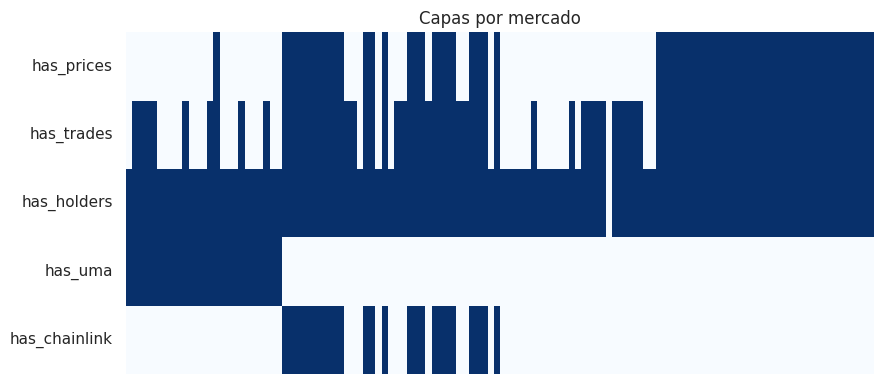

In [3]:
coverage = markets[["market_id", "cohort", "chainlink_asset_pair", "closed"]].copy()
coverage["has_prices"] = coverage["market_id"].isin(prices["market_id"].unique()) if len(prices) else False
coverage["has_trades"] = coverage["market_id"].isin(trades["market_id"].unique()) if len(trades) else False
coverage["has_holders"] = coverage["market_id"].isin(holders["market_id"].unique()) if len(holders) else False
coverage["has_uma"] = coverage["market_id"].isin(links["market_id"].unique()) if len(links) else False
coverage["has_chainlink"] = coverage["market_id"].isin(chainlink["market_id"].unique()) if len(chainlink) else False

flags = ["has_prices", "has_trades", "has_holders", "has_uma", "has_chainlink"]
pct = {f: round(100 * coverage[f].mean(), 1) for f in flags}
print("Cobertura (%):", pct)
full_stack = int((coverage[flags].sum(axis=1) == len(flags)).sum())
print(f"Mercados con 5 capas: {full_stack} de {len(coverage)}")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(coverage[flags].astype(int).T, cmap="Blues", cbar=False, yticklabels=flags, xticklabels=False, ax=ax)
ax.set_title("Capas por mercado")
plt.tight_layout()
plt.show()

### 2.2 Interpretación

De 120 mercados, el 71,7 % tiene trades, el 99,2 % holders, el 50 % serie de precios 1h, el 20,8 % enlace UMA y el 20 % serie Chainlink alineada. Ninguno tiene las cinco capas a la vez (0 de 120). Cualquier modelo o dashboard que asuma UMA o Chainlink en todos los mercados fallaría: hay que segmentar o enriquecer la extracción en una fase posterior. La cuota UMA ya aporta 25 links en esta muestra; Chainlink sigue siendo el cuello de botella para divergencia.


## 3. UMA y Gamma en la muestra

Cruzamos `market_resolution_links` con metadata Gamma para ver si el estado UMA coincide con `closed` y la cohorte asignada.


### 3.1 Cruce links y metadata


In [4]:
if len(links):
    uma = links.merge(markets[["market_id", "title", "closed", "cohort"]], on="market_id", how="left")
    print(uma["resolution_status"].value_counts())
    mismatch = uma[(uma["resolution_status"] == "resolved") & (uma["closed"] == False)]
    print("Resueltos UMA pero closed=False en Gamma:", len(mismatch))
    print(uma[["market_id", "resolution_status", "cohort", "closed"]].head(8).to_string())
else:
    print("Sin links UMA")
print("uma_audit:", manifest.get("uma_audit"))

resolution_status
resolved    21
proposed     4
Name: count, dtype: int64
Resueltos UMA pero closed=False en Gamma: 0
  market_id resolution_status      cohort  closed
0   1193251          resolved  B_resolved    True
1   1193250          resolved  B_resolved    True
2   1193249          resolved  B_resolved    True
3   1193248          resolved  B_resolved    True
4   1193243          resolved  B_resolved    True
5   1193238          resolved  B_resolved    True
6   1193229          resolved  B_resolved    True
7   1087779          resolved  B_resolved    True
uma_audit: {'uma_parsed_count': 195, 'uma_overlap_count': 25}


### 3.2 Interpretación

En la muestra enlazada hay 21 resoluciones en estado resolved y 4 en proposed (25 mercados en total). Ninguno aparece como resolved en UMA y `closed=False` en Gamma (0 inconsistencias de ese tipo), lo que sugiere que, para los mercados que sí enlazamos, Gamma y UMA están alineados en cierre. El universo global UMA tiene 195 `market_id` parseados en ancillary frente a 25 que caen en nuestra muestra: el resto de resoluciones on-chain no corresponden a los mercados líquidos/crypto que priorizamos.


## 4. Microestructura y cohortes

Comparamos spread del libro, número de trades y volatilidad del precio YES entre cohortes. Los mercados resueltos suelen tener actividad nula en la ventana reciente.


### 4.1 Métricas por cohorte


Spread mediano global: 0.998
cohort
A_active_liquid    0.998
B_resolved           NaN
D_low_liquidity      NaN
Name: spread_med, dtype: float64


Trades por cohorte (mediana):
cohort
A_active_liquid    100.0
B_resolved           0.0
D_low_liquidity      0.0
Name: n_trades, dtype: float64
Volatilidad 1h mediana por cohorte:
cohort
A_active_liquid    0.0
B_resolved         NaN
D_low_liquidity    NaN
Name: vol_1h, dtype: float64


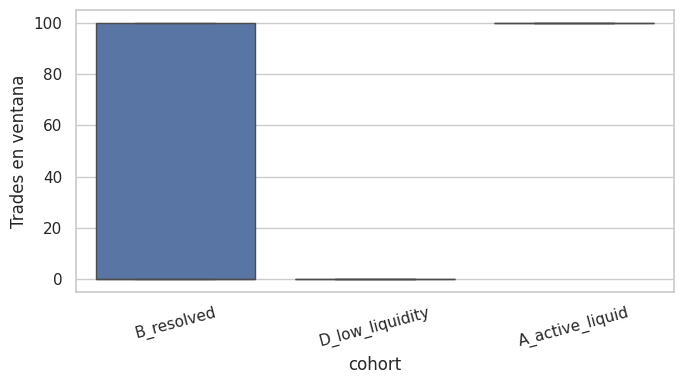

In [5]:
if len(orderbook_raw) and "spread" in orderbook_raw.columns:
    ob = orderbook_raw.copy()
    ob["market_id"] = ob["market_id"].astype(str)
    ob["spread"] = pd.to_numeric(ob["spread"], errors="coerce")
    spread_med = ob.groupby("market_id")["spread"].median()
    markets_ob = markets.set_index("market_id").join(spread_med.rename("spread_med"), how="left")
    print("Spread mediano global:", round(spread_med.median(), 4))
    print(markets_ob.groupby("cohort")["spread_med"].median())

if len(trades):
    tpc = trades.groupby("market_id").size().rename("n_trades")
    mc = markets.set_index("market_id").join(tpc, how="left").fillna(0)
    print("Trades por cohorte (mediana):")
    print(mc.groupby("cohort")["n_trades"].median())

if len(prices):
    vol = prices[prices["interval"] == "1h"].groupby("market_id")["price"].std().rename("vol_1h")
    mc2 = markets.set_index("market_id").join(vol, how="left")
    print("Volatilidad 1h mediana por cohorte:")
    print(mc2.groupby("cohort")["vol_1h"].median())

if len(trades):
    fig, ax = plt.subplots(figsize=(7, 4))
    plot_df = mc.reset_index()
    sns.boxplot(data=plot_df, x="cohort", y="n_trades", ax=ax)
    ax.set_ylabel("Trades en ventana")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

### 4.2 Interpretación

La mediana de trades en cohorte activa líquida es 100 (tope del límite API por mercado), mientras que mercados resueltos y de baja liquidez tienen mediana 0 trades en la ventana de extracción. El spread mediano del libro ronda 0,998 en la escala del endpoint (46 mercados superan el umbral 0,08 usado en reglas). La volatilidad 1h mediana es 0 en activos líquidos porque muchos precios no se mueven en la ventana corta capturada (~1 h efectiva en timestamps). El contraste útil es actividad reciente concentrada en abiertos, no comparar resueltos como si tuvieran microestructura comparable.


## 5. Catálogo de reglas (patrones explícitos)

Cada regla se evalúa mercado a mercado. La tabla resume cuántos mercados disparan cada patrón y si conviene usarlo en producto (filtro), solo como control de ETL (trivial) o descartarlo (engañoso).


### 5.1 Evaluación R1–R7


In [6]:
from app.config.settings import settings
from app.services.divergence.detectors import DETECTORS, DetectionContext, parse_severity_buckets
from app.services.divergence.service import _align, _normalize

rules = []

# R1: precio fuera de banda operativa
if len(prices):
    band = prices.groupby("market_id")["price"].agg(["min", "max"])
    hit = band[(band["min"] < 0.02) | (band["max"] > 0.98)].index.astype(str).tolist()
    rules.append({"regla": "R1_precio_extremo_1h", "n_mercados": len(hit), "tipo": "trivial_etl", "ejemplo_ids": hit[:3]})

# R2: spread ancho
if len(orderbook_raw) and "spread" in orderbook_raw.columns:
    ob2 = orderbook_raw.copy()
    ob2["market_id"] = ob2["market_id"].astype(str)
    ob2["spread"] = pd.to_numeric(ob2["spread"], errors="coerce")
    wide = ob2.groupby("market_id")["spread"].median()
    hit = wide[wide > 0.08].index.tolist()
    rules.append({"regla": "R2_spread_mediano_gt_8pct", "n_mercados": len(hit), "tipo": "util_filtro", "ejemplo_ids": hit[:3]})

# R3: sin trades pese a holders
if len(trades) and len(holders):
    t_ids = set(trades["market_id"].unique())
    h_ids = set(holders["market_id"].unique())
    hit = sorted(h_ids - t_ids)
    rules.append({"regla": "R3_holders_sin_trades", "n_mercados": len(hit), "tipo": "util_revisar", "ejemplo_ids": hit[:3]})

# R4: UMA resolved vs Gamma no cerrado
if len(links):
    uma_m = links.merge(markets[["market_id", "closed"]], on="market_id")
    hit = uma_m[(uma_m["resolution_status"] == "resolved") & (uma_m["closed"] == False)]["market_id"].tolist()
    rules.append({"regla": "R4_uma_resolved_gamma_abierto", "n_mercados": len(hit), "tipo": "util_inconsistencia", "ejemplo_ids": hit[:3]})

# R5: precio casi plano en 1h
if len(prices):
    vol2 = prices[prices["interval"] == "1h"].groupby("market_id")["price"].std()
    hit = vol2[vol2 < 0.015].index.astype(str).tolist()
    rules.append({"regla": "R5_precio_plano_1h", "n_mercados": len(hit), "tipo": "util_priorizar", "ejemplo_ids": hit[:3]})

# R6: Pearson crudo prob vs USD (engañoso)
pearson_eng = []
if len(chainlink):
    for mid in chainlink["market_id"].astype(str).unique():
        m = prices[(prices["market_id"] == mid) & (prices["interval"] == "1h")]["price"].astype(float)
        c = chainlink[chainlink["market_id"].astype(str) == mid]["chainlink_price_usd"].astype(float)
        n = min(len(m), len(c))
        if n >= 5:
            r = np.corrcoef(m.iloc[-n:], c.iloc[-n:])[0, 1]
            if abs(r) > 0.85:
                pearson_eng.append(mid)
    rules.append({"regla": "R6_pearson_alto_crudo", "n_mercados": len(pearson_eng), "tipo": "enganoso", "ejemplo_ids": pearson_eng[:3]})

# R7: detectores divergencia (util si serie densa)
SB = parse_severity_buckets(settings.DIVERGENCE_SEVERITY_BUCKETS)
gap_hits = []
for mid in chainlink["market_id"].astype(str).unique() if len(chainlink) else []:
    mkt = prices[(prices["market_id"] == mid) & (prices["interval"] == "1h")].sort_values("timestamp_unix")
    ext = chainlink[chainlink["market_id"].astype(str) == mid].sort_values("timestamp_unix")
    if len(mkt) < 4 or len(ext) < 4:
        continue
    mv, ev = mkt["price"].astype(float).tolist(), ext["chainlink_price_usd"].astype(float).tolist()
    mn, en = _align(_normalize(mv), _normalize(ev))
    if len(mn) < 2:
        continue
    ctx = DetectionContext(
        market_norm=mn, external_norm=en, market_raw_last=float(mv[-1]),
        time_window_minutes=settings.DIVERGENCE_WINDOW_MINUTES,
        external_source=str(ext["asset_pair"].iloc[0]),
        gap_min_pct=settings.DIVERGENCE_GAP_MIN_PCT,
        ext_move_min_pct=settings.DIVERGENCE_EXT_MOVE_MIN_PCT,
        mkt_flat_max_pct=settings.DIVERGENCE_MKT_FLAT_MAX_PCT,
        severity_buckets=SB,
    )
    for det in DETECTORS:
        if det.detect(ctx):
            gap_hits.append({"market_id": mid, "detector": det.divergence_type})
rules.append({"regla": "R7_detector_divergencia", "n_mercados": len({h["market_id"] for h in gap_hits}), "tipo": "util_divergencia", "ejemplo_ids": list({h["market_id"] for h in gap_hits})[:3]})

rules_df = pd.DataFrame(rules)
print(rules_df.to_string(index=False))
if gap_hits:
    print("Detalle detectores:")
    print(pd.DataFrame(gap_hits).head(10).to_string(index=False))

                        regla  n_mercados                tipo                 ejemplo_ids
         R1_precio_extremo_1h          41         trivial_etl [1057883, 1393068, 1393070]
    R2_spread_mediano_gt_8pct          46         util_filtro [1057883, 1057916, 1339767]
        R3_holders_sin_trades          33        util_revisar     [109, 1193238, 1193243]
R4_uma_resolved_gamma_abierto           0 util_inconsistencia                          []
           R5_precio_plano_1h          60      util_priorizar [1057883, 1057916, 1339767]
        R6_pearson_alto_crudo          11            enganoso  [573655, 1057883, 1057916]
      R7_detector_divergencia           5    util_divergencia   [701501, 1339768, 701553]
Detalle detectores:
market_id               detector
   701501 price_gap_vs_chainlink
   701552 price_gap_vs_chainlink
   701495 price_gap_vs_chainlink
   701553 price_gap_vs_chainlink
  1339768 price_gap_vs_chainlink


/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### 5.2 Utilidad en producto

La tabla anterior resume el disparo mercado a mercado. Abajo interpretamos **qué reglas existen**, **cuáles sirven en producto** y **cuáles no**.

#### R1 — Precio extremo en ventana 1h (41 mercados, tipo trivial ETL)

Dispara cuando el mínimo o máximo del precio YES en 1h sale de la banda operativa habitual (por debajo de 0,02 o por encima de 0,98). **Utilidad en producto: baja** como alerta de riesgo: en mercados crypto es normal acercarse a 0 o 1. **Sí sirve** como control de sanidad del histórico CLOB (confirma que la serie 1h tiene rango útil). No priorizar colas de revisión humana solo por R1.

#### R2 — Spread mediano del libro > 8 % (46 mercados, filtro de liquidez)

Identifica mercados donde el libro CLOB es poco informativo en la escala del endpoint (spread mediano global ~0,998). **Utilidad: alta.** Conviene **excluir o bajar prioridad** en rankings y alertas automáticas cuando R2 dispara: el precio mid puede moverse poco reflejando liquidez real. Calibrar el umbral 0,08 con negocio si la escala del API cambia.

#### R3 — Holders sin trades en ventana (33 mercados, cola de revisión)

Hay posición registrada en Data API pero ningún trade en la ventana extraída. **Utilidad: media.** Apunta a posición “dormida”, mercados illíquidos o límite temporal de la API — no implica por sí solo manipulación. Útil para **priorizar revisión cualitativa** junto con R2, no como bloqueo automático.

#### R4 — UMA resolved vs Gamma abierto (0 mercados, guardrail)

En la muestra enlazada **no dispara**: no hay resolved en UMA con `closed=False` en Gamma. **Utilidad: alta como guardrail** cuando en el futuro aparezca un caso: sería inconsistencia fuerte entre resolución on-chain y estado de mercado. Limitación: solo 25 mercados con link UMA; 0 hoy es señal positiva local, no prueba global sobre los 195 IDs UMA del ancillary.

#### R5 — Precio casi plano en 1h (60 mercados, priorización)

Volatilidad estándar del precio YES en 1h por debajo de 0,015. **Utilidad: media** para **ordenar colas** (mercados quietos vs activos). Puede confundir “sin movimiento” con “sin datos”; combinar con cobertura de `price_series` (cap. 2).

#### R6 — Correlación Pearson cruda prob vs USD (11 mercados, engañoso)

Correlación alta entre precio YES y `chainlink_price_usd` sin normalización alineada. **Utilidad: ninguna para divergencia.** Genera **falsos positivos** al mezclar probabilidad con precio spot en USD. **Descartar en producto**; no usar como sustituto de los detectores del paquete `app.services.divergence`.

#### R7 — Detectores de divergencia offline (5 mercados, interpretable)

Replay de `DETECTORS` (`PriceGapDetector`, `ChainlinkMoveNoMarketDetector`, etc.) con la misma normalización y alineación que en servicio. En este snapshot disparan **5 mercados** (p. ej. 701495, 701501, 701552, 701553, 1339768) con tipo `price_gap_vs_chainlink`. **Utilidad: alta** para **cola de analista**: señales explicables con gap % y ventana configurada. Limitación: solo 24 mercados tienen serie Chainlink alineada y la ventana temporal es corta — validar densidad antes de alertas automáticas.

#### Jerarquía recomendada

| Prioridad | Reglas | Uso |
|-----------|--------|-----|
| Operaciones / cola | R2, R7, R3 | Filtro liquidez, divergencia interpretable, revisión holders sin trades |
| Priorización | R1, R5 | Sanity ETL y mercados quietos |
| Vigilancia | R4 | Guardrail UMA↔Gamma |
| Prohibido | R6 | No usar en producto |

**Este snapshot sí aporta señales accionables:** 46 mercados con spread ancho, 5 con gap Chainlink replayado, 33 con holders sin trades — no es un informe vacío.



## 6. Concentración de participación (Data API)

Medimos si el notional de trades se reparte o se concentra en pocas wallets.


### 6.1 Notional por wallet


Wallets unicas: 3450
Top-1: 10.5% del notional
Top-10: 41.4% del notional


/tmp/ipykernel_52/338326911.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


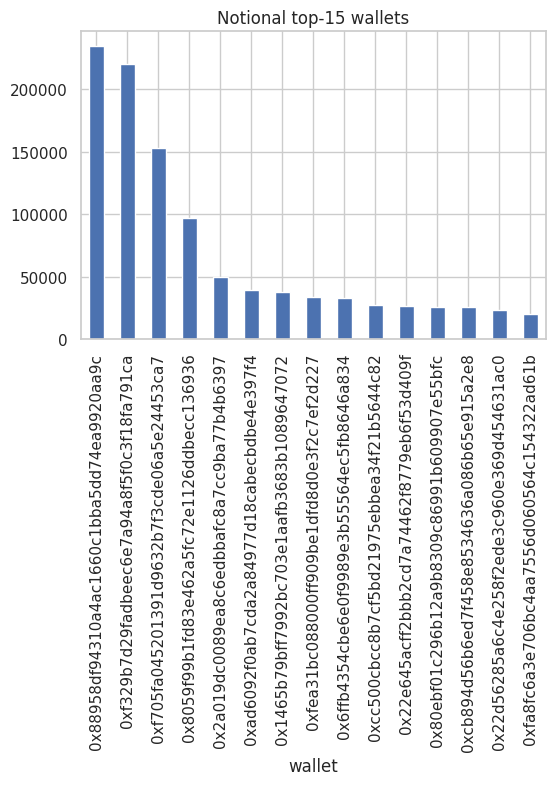

In [7]:
if len(trades):
    t2 = trades.copy()
    t2["notional"] = t2["price"].fillna(0) * t2["size"].fillna(0)
    wv = t2.groupby("wallet")["notional"].sum().sort_values(ascending=False)
    total = wv.sum()
    top1 = 100 * wv.iloc[0] / total if len(wv) and total else 0
    top10 = 100 * wv.head(10).sum() / total if total else 0
    print(f"Wallets unicas: {len(wv)}")
    print(f"Top-1: {top1:.1f}% del notional")
    print(f"Top-10: {top10:.1f}% del notional")
    fig, ax = plt.subplots(figsize=(6, 4))
    wv.head(15).plot(kind="bar", ax=ax, title="Notional top-15 wallets")
    plt.tight_layout()
    plt.show()

### 6.2 Interpretación

Hay 3450 wallets únicas en 8600 trades. El wallet líder concentra solo el 10,5 % del notional y el top-10 el 41,4 %: la actividad no es ultra-oligopólica en este snapshot, aunque sigue habiendo cola larga de participantes pequeños. Para priorizar revisión humana tiene más sentido seguir mercados con R2/R7 que buscar un único whale global.


## 7. Experimento predictivo (baselines vs MLP)

Predecimos el siguiente precio YES en mercados con al menos 30 puntos 1h. Features: tres lags, liquidez, spread, flags UMA y Chainlink. Comparamos persistencia (último precio), regresión lineal y un MLP de dos capas ocultas.


### 7.1 Panel y MAE


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
MIN_POINTS = 30
rows = []
mkt_feats = markets.set_index("market_id")
for mid, grp in prices[prices["interval"] == "1h"].groupby("market_id"):
    grp = grp.sort_values("timestamp_unix")
    if len(grp) < MIN_POINTS + 1:
        continue
    p = grp["price"].astype(float).values
    meta = mkt_feats.loc[mid] if mid in mkt_feats.index else None
    liq = float(meta["liquidity"]) if meta is not None and pd.notna(meta.get("liquidity")) else 0.0
    spr = float(meta["spread"]) if meta is not None and pd.notna(meta.get("spread")) else 0.0
    has_cl = 1.0 if meta is not None and pd.notna(meta.get("chainlink_asset_pair")) else 0.0
    has_uma = 1.0 if len(links) and mid in set(links["market_id"]) else 0.0
    for i in range(3, len(p) - 1):
        rows.append({
            "market_id": mid,
            "y": p[i + 1],
            "lag1": p[i],
            "lag2": p[i - 1],
            "lag3": p[i - 2],
            "liquidity": liq,
            "spread": spr,
            "has_chainlink": has_cl,
            "has_uma": has_uma,
        })
panel = pd.DataFrame(rows)
print("Filas panel:", len(panel), "mercados:", panel["market_id"].nunique())
if len(panel) < 200:
    print("Panel demasiado pequeño para NN fiable; saltamos entrenamiento.")
    nn_mae = lin_mae = pers_mae = None
else:
    feat_cols = ["lag1", "lag2", "lag3", "liquidity", "spread", "has_chainlink", "has_uma"]
    X = panel[feat_cols].values
    y = panel["y"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    pers_pred = X_test[:, 0]
    pers_mae = mean_absolute_error(y_test, pers_pred)
    lin = LinearRegression().fit(X_train_s, y_train)
    lin_mae = mean_absolute_error(y_test, lin.predict(X_test_s))
    mlp = MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=400, random_state=42)
    mlp.fit(X_train_s, y_train)
    nn_mae = mean_absolute_error(y_test, mlp.predict(X_test_s))
    print(f"MAE persistencia (lag1): {pers_mae:.5f}")
    print(f"MAE regresion lineal:     {lin_mae:.5f}")
    print(f"MAE MLP (32,16):          {nn_mae:.5f}")


Filas panel: 3421 mercados: 60
MAE persistencia (lag1): 0.00008
MAE regresion lineal:     0.00014
MAE MLP (32,16):          0.00753


### 7.2 Implicaciones para producto

El panel de predicción tiene 3421 filas en 60 mercados con al menos 30 puntos 1h. En holdout (25 % aleatorio), el **MAE de persistencia** (predecir el último precio, `lag1`) es **0,00008**, el de **regresión lineal** **0,00014** y el del **MLP (32, 16)** **0,00753** — es decir, el MLP es del orden de **100× peor** que un baseline casi trivial.

**Por qué gana la persistencia.** En ventanas 1h el precio YES es muy autocorrelado: el siguiente punto suele ser casi igual al anterior. El MLP tiene muchos parámetros frente a pocas filas efectivas por mercado y las features de liquidez, spread y flags UMA/Chainlink son **constantes dentro de cada mercado** en este panel, así que no aportan variación temporal que el modelo pueda explotar. La regresión lineal tampoco supera a `lag1`: la señal útil ya está en el último precio.

**Qué hacer en producto.** No tiene sentido **desplegar una red neuronal** para predecir el siguiente tick de precio YES con este snapshot y este diseño de features. **Sí tiene sentido** desplegar **detectores interpretables** (R7, alineados con `app.services.divergence`) y **reglas de liquidez y cobertura** (R2, R5, segmentación del cap. 2): son explicables, baratos de mantener y acordes con la calidad de los datos.

**Valor del experimento.** El MLP no es un fracaso del análisis: es un **experimento negativo útil** que fija un techo — si un baseline de una línea gana por dos órdenes de magnitud, cualquier roadmap de ML para precio debe cambiar objetivo (p. ej. evento de divergencia, riesgo de resolución) o exigir **más histórico por mercado**, features que varíen en el tiempo y un horizonte distinto al “siguiente punto 1h”.

**Condiciones mínimas para reconsiderar modelos** (sin implicar nueva extracción en este cuaderno): series mucho más largas por `market_id`, features intra-mercado que cambien en cada fila del panel, y una etiqueta alineada con negocio (no solo MAE de precio en ventana corta).



## 8. Conclusiones

Síntesis de lo medido en este snapshot, con referencia directa a las celdas anteriores.


### 8.1 Hallazgos que el snapshot valida

1. **ETL de precios y trades coherente (cap. 1).** `price_series` y `trades` no pierden filas por valores imposibles; las probabilidades CLOB ya vienen en [0, 1].
2. **Puente Gamma–Data API fuerte.** ~72 % de mercados con trades, ~99 % con holders: la capa de participación y actividad reciente es explotable.
3. **Submuestra UMA–Gamma alineada.** 21 resolved + 4 proposed en 25 links, 0 conflictos R4: donde enlazamos, cierre on-chain y metadata Gamma coinciden.
4. **Microestructura distinguible por cohorte (cap. 4).** Actividad concentrada en `A_active_liquid` (mediana 100 trades) frente a silencio en resueltos y baja liquidez.
5. **Reglas con señal accionable (cap. 5).** 46 mercados R2 (liquidez), 5 R7 (divergencia replay), 33 R3 (holders sin trades) — material concreto para filtros y colas.
6. **Participación no ultra-concentrada (cap. 6).** Top-1 ~10,5 % del notional; la cola de wallets es larga pero no domina un único actor.

### 8.2 Límites del alcance y acciones

**Límites.** Chainlink y UMA no cubren toda la muestra (~20 % cada uno); **ningún mercado tiene las cinco capas** a la vez. Las inferencias de divergencia global no son válidas: solo aplican al subconjunto con serie alineada y ventana corta. Correlación Pearson cruda (R6) y MLP para precio quedan **descartados** con evidencia numérica.

**Acciones recomendadas (con los datos actuales, sin nueva extracción aquí):**

- Implementar o reforzar en producto **filtro R2** y **cola R7** para revisión de divergencia Chainlink.
- Usar **R3** como señal secundaria de revisión (posición sin trades), no como bloqueo automático.
- Mantener **R4** como guardrail UMA↔Gamma en pipelines de resolución.
- **No usar R6** ni desplegar NN para predicción de precio YES en ventana 1h.
- En una **próxima** extracción (fuera de este cuaderno), priorizar más histórico Chainlink y cuota UMA para no perder el puente ancillary↔Gamma en mercados líquidos.

